<a href="https://colab.research.google.com/github/CassandreDGN/PROJET_GPI_CD/blob/master/PROJET_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet de GPI**:

##First step : binning the image to run the code faster

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

%pip install Bio

import urllib.request
#import io
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

%pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.4/321.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=ed988090-e60e-43d9-960e-b709902ff00c
To: /content/map.mrc
100%|██████████| 228M/228M [00:03<00:00, 66.8MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: singlegrowing upbrain map 2D image


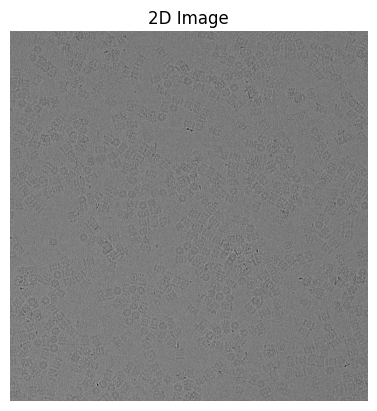

In [2]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: singlegrowing upbrain map 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

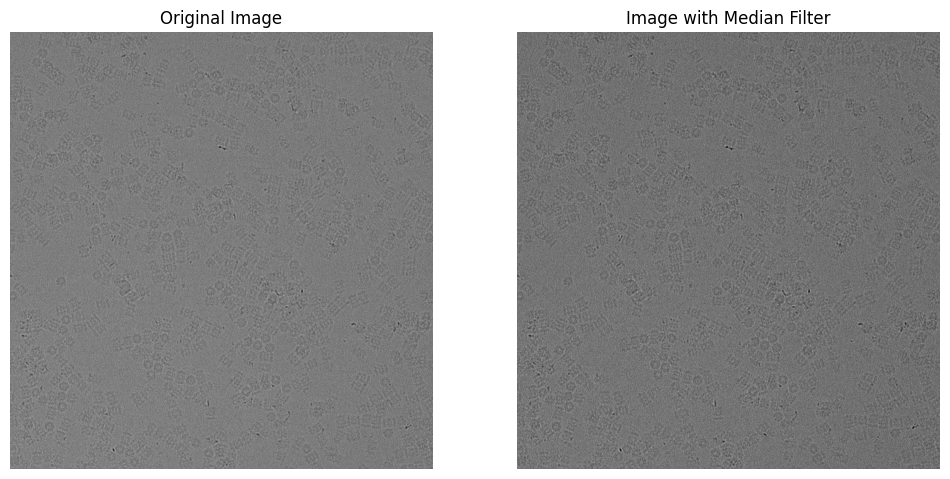

In [3]:
#add filter on picture to denoise before doing anything else

# Apply median filter
median_filtered_image = ndimage.median_filter(data, size=3)
median_filtered_image = np.clip(median_filtered_image, 0, 255).astype(np.uint8)

# Display the original and filtered images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(data, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(median_filtered_image, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[1].set_title('Image with Median Filter')
ax[1].axis('off')

plt.show()

In [4]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

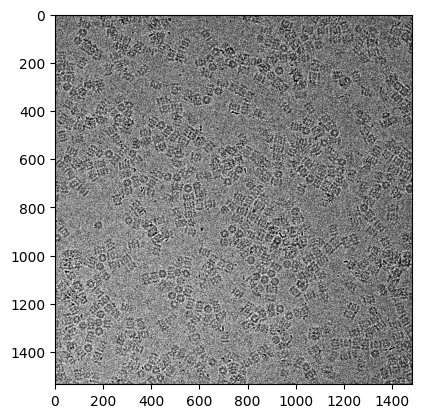

In [5]:
file_binned = bin_image(median_filtered_image,5)

plt.imshow(file_binned,cmap='gray', vmin=np.percentile(file_binned, 5), vmax=np.percentile(file_binned, 95))

array([[ 0.02432298,  0.02432298, -1.10724916, ..., -1.10724916,
        -1.10724916,  0.02432298],
       [ 0.02432298,  0.02432298,  0.02432298, ...,  0.02432298,
         1.15589513, -2.2388213 ],
       [ 1.15589513,  1.15589513,  1.15589513, ..., -1.10724916,
        -1.10724916, -1.10724916],
       ...,
       [-1.10724916,  0.02432298,  1.15589513, ..., -2.2388213 ,
        -1.10724916, -1.10724916],
       [ 1.15589513, -1.10724916,  0.02432298, ..., -1.10724916,
         0.02432298,  1.15589513],
       [ 0.02432298,  0.02432298,  2.28746727, ..., -1.10724916,
         1.15589513,  0.02432298]])

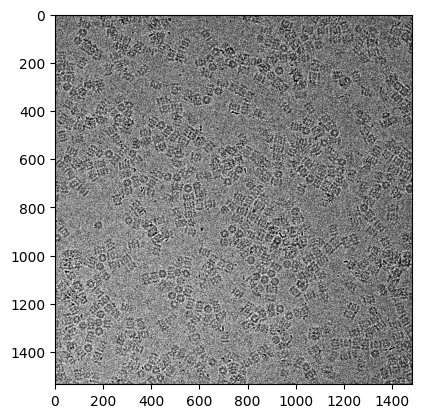

In [6]:
from mrcfile.dtypes import normalise_byte_order
#normalize image : substract average and divide by max

normalized_data = (file_binned - np.mean(file_binned)) / np.std(file_binned)




vmin2 = np.percentile(normalized_data, 5)
vmax2 = np.percentile(normalized_data, 95)  #have to change vmax value to use the new ones

plt.imshow(normalized_data,cmap='gray',vmin=vmin2, vmax=vmax2)

normalized_data

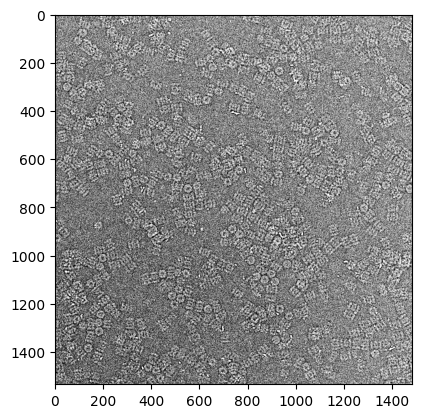

In [7]:
# inverting picture

binned_normalized_inverted_img = normalized_data*(-1)
plt.imshow(binned_normalized_inverted_img,cmap='gray', vmin=np.percentile(binned_normalized_inverted_img, 5), vmax=np.percentile(binned_normalized_inverted_img, 95))


In [8]:
# Padding(ton?)
# Function to apply different padding modes
def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:rana
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded


to exctrat coordinates we need to figure out a threshold

In [9]:
#padded_image = apply_padding(normalized_data, 400, mode= 'constant', constant_value=255)

padded_image = apply_padding(binned_normalized_inverted_img, 70, mode= 'edge')

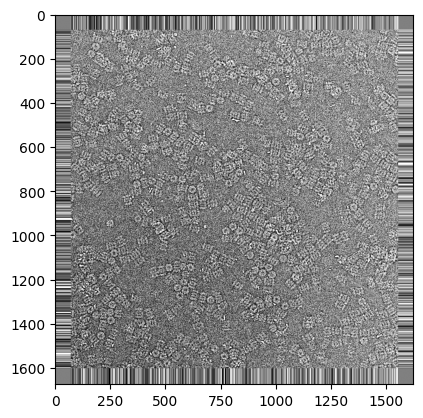

In [10]:
plt.imshow(padded_image,cmap='gray',vmin=np.percentile(padded_image, 5),vmax=np.percentile(padded_image, 95))

### still have to denoise and crop to make test image but anyway moving on

## Projection

PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS

📚 WHAT IS A PDB FILE?

PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research


📥 FETCHING PDB STRUCTURE: 6BDF
✓ Successfully downloaded 3885327 bytes
✓ Saved to 6BDF.pdb

🔬 STR

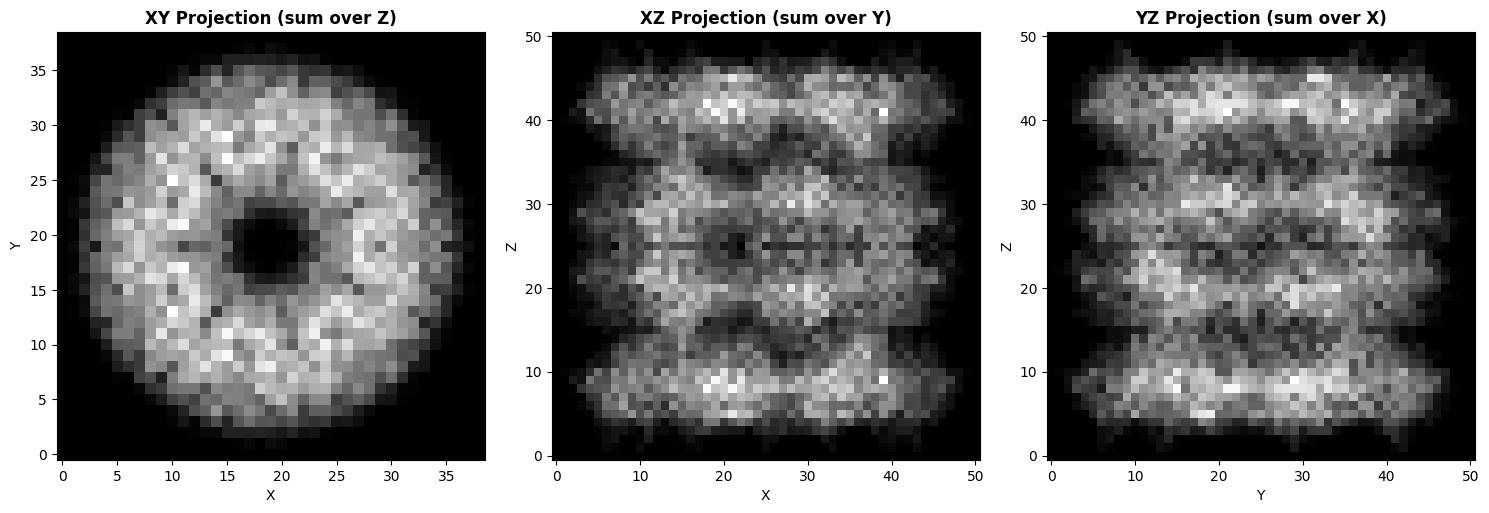


Summed Density Projections:
  - Pixel intensity = number of atoms projected into that pixel
  - Brighter = higher density
  - Approximates ideal projection images (no noise, no CTF)


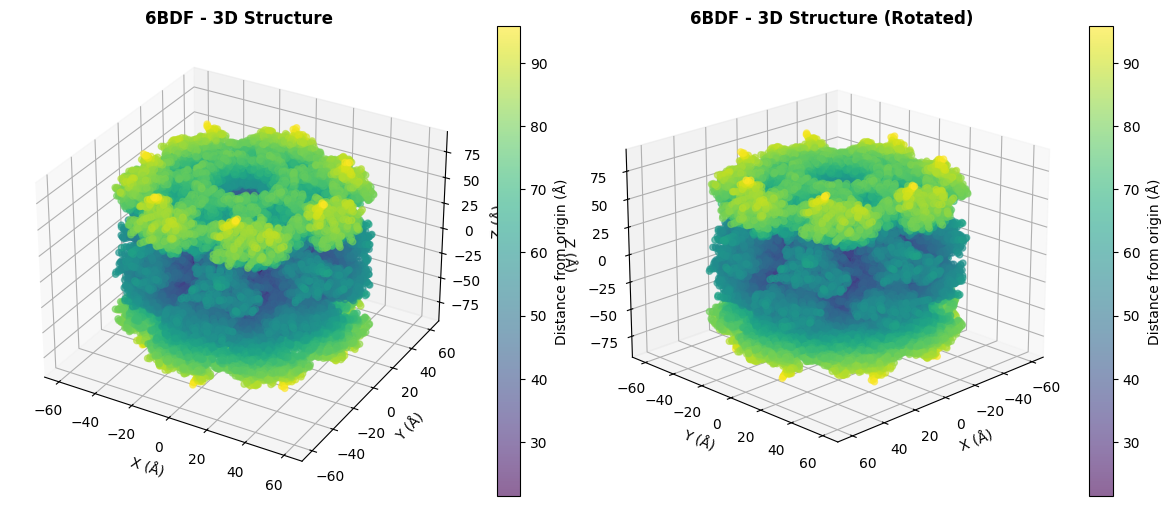

In [11]:
print("="*70)
print("PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS")
print("="*70)

print("\n" + "="*70)
print("📚 WHAT IS A PDB FILE?")
print("="*70)
print("""
PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research
""")

print("\n" + "="*70)
print("📥 FETCHING PDB STRUCTURE: 6BDF")
print("="*70)

pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"✓ Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"✓ Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    print("\n" + "="*70)
    print("🔬 STRUCTURE INFORMATION")
    print("="*70)

    # Extract information
    model = structure[0]
    chains = list(model.get_chains())

    print(f"\nStructure ID: {pdb_id}")
    print(f"Number of models: {len(structure)}")
    print(f"Number of chains: {len(chains)}")

    for chain in chains:
        residues = list(chain.get_residues())
        atoms = list(chain.get_atoms())
        print(f"\nChain {chain.id}:")
        print(f"  - Residues: {len(residues)}")
        print(f"  - Atoms: {len(atoms)}")


    # Extract t 7: Manipulating a PDt 7: Manipulating a PD coordinates
    print("\n" + "="*70)
    print("🧬 ATOMIC COORDINATES FROM 6BDF")
    print("="*70)

    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })

    print(f"Total atoms: {len(all_atoms)}")
    print(f"\nFirst 10 atoms:")
    print(f"{'Atom':6} {'Residue':8} {'Res#':5} {'X (Å)':10} {'Y (Å)':10} {'Z (Å)':10} {'B-factor':10}")
    print("-" * 60)
    for atom in all_atoms[:10]:
        print(f"{atom['name']:6} {atom['residue']:8} {atom['residue_id']:5d} {atom['x']:10.3f} {atom['y']:10.3f} {atom['z']:10.3f} {atom['b_factor']:10.2f}")

    # Extract coordinates for visualization
    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")

    print("\n" + "="*70)
    print("🎯 CREATING DENSITY-BASED 2D PROJECTIONS (SUMMED GRAYSCALE)")
    print("="*70)

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)
    padding = 5     # Å padding around structure

    # =========================================================================
    # 1. DEFINE PROJECTION ENGINE FIRST
    # =========================================================================
    def create_projection(coord1, coord2, bins=256):
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # 2D histogram (counts = density)
        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                           range=[[min1, max1], [min2, max2]])
        return H / H.max()

    # =========================================================================
    # 2. DYNAMIC CANVAS RESOLUTION SCALE (Zero Hardcoded Values)
    # =========================================================================
    total_physical_span = coords_centered.max() - coords_centered.min()
    angstroms_per_pixel = total_physical_span / 48.0  # Dynamic baseline aspect ratio

    # =========================================================================
    # 3. RUN PROJECTIONS (Updating the single 'img_size' variable on the fly)
    # =========================================================================

    # XY (Top View)
    span_xy = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                  coords_centered[:, 1].max() - coords_centered[:, 1].min()) + (2 * padding)
    img_size = int(np.ceil(span_xy / angstroms_per_pixel))
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)

    # XZ (Side View)
    span_xz = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                  coords_centered[:, 2].max() - coords_centered[:, 2].min()) + (2 * padding)
    img_size = int(np.ceil(span_xz / angstroms_per_pixel))
    proj_xz = create_projection(coords_centered[:, 0], coords_centered[:, 2], img_size)

    # YZ (Alternate Side View)
    span_yz = max(coords_centered[:, 1].max() - coords_centered[:, 1].min(),
                  coords_centered[:, 2].max() - coords_centered[:, 2].min()) + (2 * padding)
    img_size = int(np.ceil(span_yz / angstroms_per_pixel))
    proj_yz = create_projection(coords_centered[:, 1], coords_centered[:, 2], img_size)

    # =========================================================================

    # Plot projections
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY projection
    axes[0].imshow(proj_xy.T, cmap='gray', origin='lower')
    axes[0].set_title('XY Projection (sum over Z)', fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # XZ projection
    axes[1].imshow(proj_xz.T, cmap='gray', origin='lower')
    axes[1].set_title('XZ Projection (sum over Y)', fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # YZ projection
    axes[2].imshow(proj_yz.T, cmap='gray', origin='lower')
    axes[2].set_title('YZ Projection (sum over X)', fontweight='bold')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.tight_layout()
    plt.show()

    print("\nSummed Density Projections:")
    print("  - Pixel intensity = number of atoms projected into that pixel")
    print("  - Brighter = higher density")
    print("  - Approximates ideal projection images (no noise, no CTF)")

    # 3D visualization
    fig = plt.figure(figsize=(12, 5))

    # 3D scatter plot
    ax4 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter = ax4.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                          c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax4.set_xlabel('X (Å)', fontsize=10)
    ax4.set_ylabel('Y (Å)', fontsize=10)
    ax4.set_zlabel('Z (Å)', fontsize=10)
    ax4.set_title(f'{pdb_id} - 3D Structure', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Distance from origin (Å)')

    # 3D scatter plot - rotated view
    ax5 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax5.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                           c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax5.view_init(elev=20, azim=45)  # Different viewing angle
    ax5.set_xlabel('X (Å)', fontsize=10)
    ax5.set_ylabel('Y (Å)', fontsize=10)
    ax5.set_zlabel('Z (Å)', fontsize=10)
    ax5.set_title(f'{pdb_id} - 3D Structure (Rotated)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=ax5, label='Distance from origin (Å)')

    plt.tight_layout()
    plt.show()


except urllib.error.URLError as e:
    print(f"❌ Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")

cut the micrograph in very little little pieces to test the cross-correlation without spending 5hours and 52 minutes waiting for the script to run cause that would be really fucking fucking dumb ngl

also figure out how to get the images in tif format like are they? are they not?

In [12]:
def normalized_cross_correlation(image, template):
    """
    Perform normalized cross-correlation.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for

    Returns:
    --------
    output : 2D numpy array
        Normalized cross-correlation (values between -1 and 1)
    """
    img_h, img_w = image.shape
    tmp_h, tmp_w = template.shape

    out_h = img_h - tmp_h + 1
    out_w = img_w - tmp_w + 1

    output = np.zeros((out_h, out_w))

    # Normalize template (subtract mean)
    template_mean = template.mean()
    template_norm = template - template_mean
    template_std = np.sqrt(np.sum(template_norm ** 2))

    # Avoid division by zero
    if template_std == 0:
        return output

    # Slide template over image
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+tmp_h, j:j+tmp_w]

            # Normalize region
            region_mean = region.mean()
            region_norm = region - region_mean
            region_std = np.sqrt(np.sum(region_norm ** 2))

            # Avoid division by zero
            if region_std == 0:
                output[i, j] = 0
            else:
                # Normalized cross-correlation
                output[i, j] = np.sum(region_norm * template_norm) / (region_std * template_std)

    return output

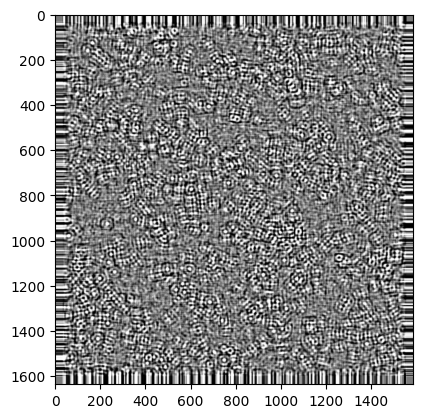

In [13]:
ncc_image = normalized_cross_correlation(padded_image, proj_xy)
plt.imshow(ncc_image,cmap='gray',vmin=np.percentile(ncc_image, 5),vmax=np.percentile(ncc_image, 95))


In [14]:
  def template_matching(image, template, method='ncc'):
    """
    Perform template matching with padding.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for
    method : str
        'ncc' for normalized cross-correlation
        'cc' for simple cross-correlation

    Returns:
    --------
    result : 2D numpy array (same size as input image)
        Matching score map
    """
    tmp_h, tmp_w = template.shape
    pad_h, pad_w = tmp_h // 2, tmp_w // 2

    # Pad image
    padded = np.pad(image,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant',
                    constant_values=0)

    # Perform matching
    if method == 'ncc':
        result = normalized_cross_correlation(padded, template)
    else:
        result = cross_correlation(padded, template)

    return result



# Apply template matching
match_result = template_matching(padded_image, proj_xy, method='ncc')

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate, maximum_filter
import matplotlib.patches as patches

def multi_angle_template_matching(image, template, angle_step=10, method='ncc'):
    """
    Rotates the template to find rectangular objects at any orientation.
    Returns the maximum correlation score map across all angles.
    """
    max_response = np.zeros_like(image, dtype=float)
    angles = np.arange(0, 360, angle_step)

    print(f"Scanning {len(angles)} orientations...")

    for angle in angles:
        # reshape=True automatically expands the bounding box
        rotated_template = rotate(template, angle, reshape=True, mode='constant', cval=0.0)

        # Run matching for this orientation (using your existing function)
        match_result = template_matching(image, rotated_template, method=method)

        # Trim match_result if padding caused a 1px offset
        match_result = match_result[:image.shape[0], :image.shape[1]]

        # Keep the highest score for each pixel across all orientations
        max_response = np.maximum(max_response, match_result)

    return max_response

def extract_objects(response_map, threshold=0.7, min_distance=15):
    """
    Extracts object coordinates using a threshold and Non-Maximum Suppression (NMS).
    """
    # 1. Apply threshold
    above_thresh = response_map >= threshold

    # 2. Local Maxima Filter (NMS)
    local_max = maximum_filter(response_map, size=min_distance) == response_map

    # 3. Valid hits must be BOTH a local peak AND above our threshold
    peaks = above_thresh & local_max

    # Extract coordinates (y, x) -> (row, col)
    y_coords, x_coords = np.where(peaks)

    return list(zip(x_coords, y_coords))

In [16]:
'''# 1. Slide the circle template across the full image
print("Scanning full image for circular top views...")
top_view_heatmap = template_matching(padded_image, proj_xy, method='ncc')

# 2. Wipe out the 70px border values in the heatmap so they can't be picked
border = 70
top_view_heatmap_clean = top_view_heatmap.copy()
top_view_heatmap_clean[:border, :] = 0  # Top border
top_view_heatmap_clean[-border:, :] = 0 # Bottom border
top_view_heatmap_clean[:, :border] = 0  # Left border
top_view_heatmap_clean[:, -border:] = 0 # Right border

# 3. Extract peaks from the cleaned map
thresh_top = 0.24  # Tweak this based on your earlier test
detected_tops = extract_objects(top_view_heatmap_clean, threshold=thresh_top, min_distance=15)
print(f"Found {len(detected_tops)} Top Views (ignoring the padding border)!")

# 4. Draw the full result
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(padded_image, cmap='gray',
          vmin=np.percentile(padded_image, 5),
          vmax=np.percentile(padded_image, 95))
ax.set_title(f'Detected Top Views (Excluding 70px Padding)')

h_top, w_top = proj_xy.shape
for x, y in detected_tops:
    rect = patches.Rectangle((x - w_top//2, y - h_top//2), w_top, h_top,
                             linewidth=2, edgecolor='cyan', facecolor='none')
    ax.add_patch(rect)

plt.show()'''

'# 1. Slide the circle template across the full image\nprint("Scanning full image for circular top views...")\ntop_view_heatmap = template_matching(padded_image, proj_xy, method=\'ncc\')\n\n# 2. Wipe out the 70px border values in the heatmap so they can\'t be picked\nborder = 70\ntop_view_heatmap_clean = top_view_heatmap.copy()\ntop_view_heatmap_clean[:border, :] = 0  # Top border\ntop_view_heatmap_clean[-border:, :] = 0 # Bottom border\ntop_view_heatmap_clean[:, :border] = 0  # Left border\ntop_view_heatmap_clean[:, -border:] = 0 # Right border\n\n# 3. Extract peaks from the cleaned map\nthresh_top = 0.24  # Tweak this based on your earlier test\ndetected_tops = extract_objects(top_view_heatmap_clean, threshold=thresh_top, min_distance=15)\nprint(f"Found {len(detected_tops)} Top Views (ignoring the padding border)!")\n\n# 4. Draw the full result\nfig, ax = plt.subplots(1, 1, figsize=(12, 10))\nax.imshow(padded_image, cmap=\'gray\',\n          vmin=np.percentile(padded_image, 5),\n    

Scanning for Top Views (Circles)...
 -> Found 111 valid center Top Views.
Scanning for Side Views (Multi-angle OpenCV)...
 -> Found 657 valid center Side Views.


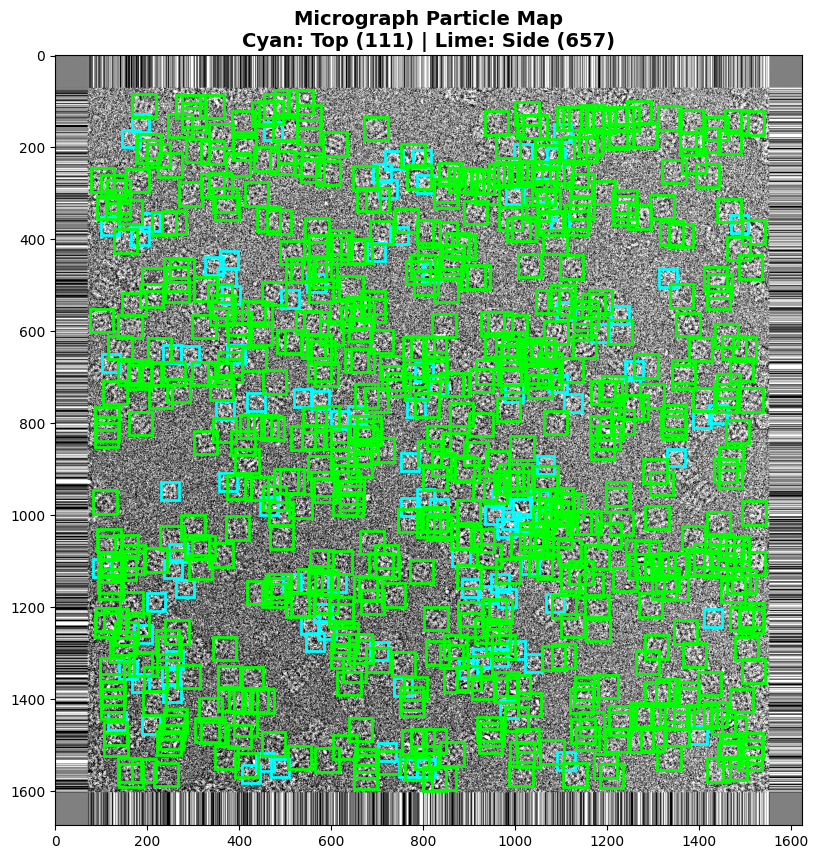

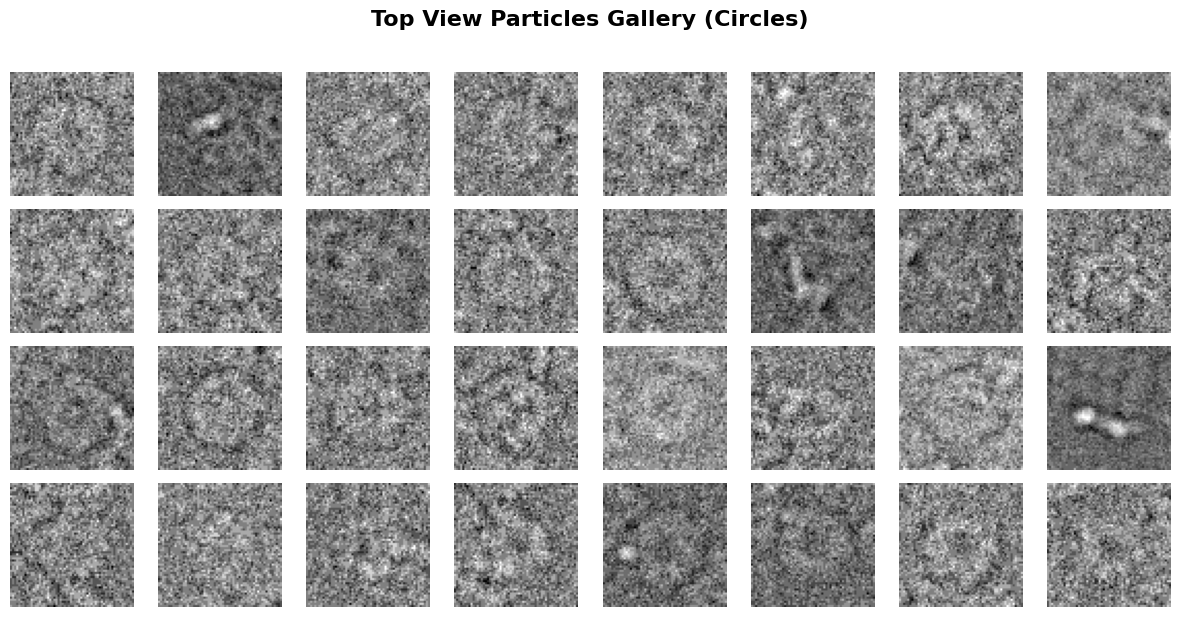

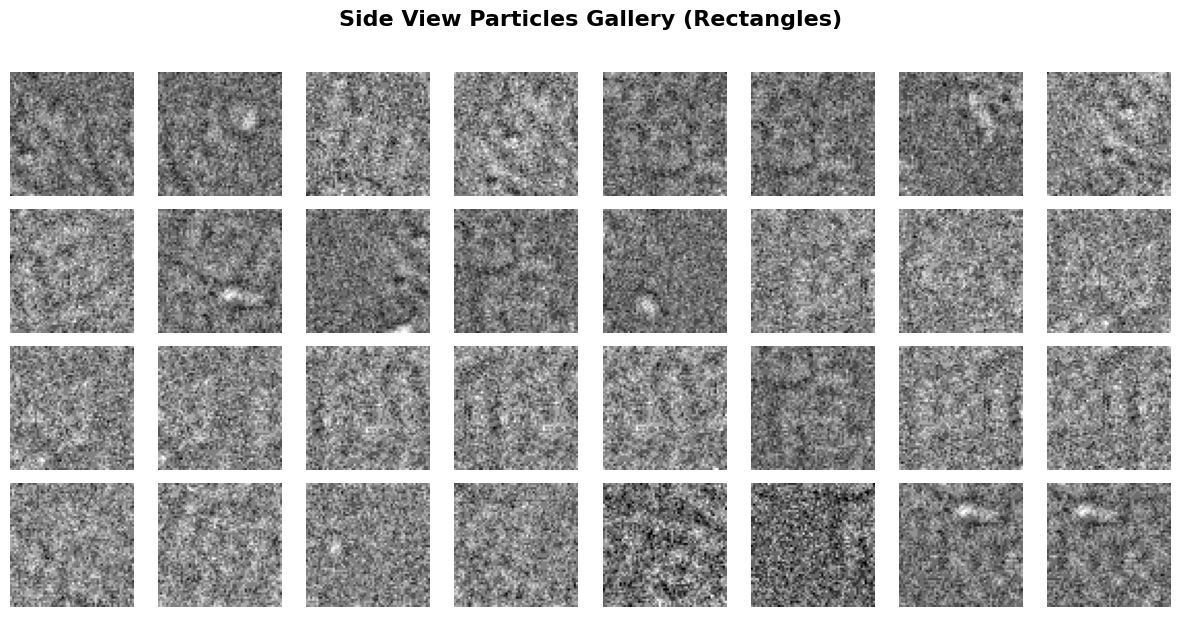

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import rotate

# =========================================================================
# 1. PARAMETERS & INPUT EXTRACTION SETTINGS
# =========================================================================
border = 70             # Strict padding width to ignore
min_dist = 20           # Minimum distance between particles to prevent overlap
thresh_top = 0.23      # Proven threshold for circles
thresh_side = 0.12      # Adjusted down for OpenCV side-views to catch rectangles

# Set a standard box size for cropping your final gallery
box_size = max(max(proj_xy.shape), max(proj_xz.shape)) + 10
half_box = box_size // 2
img_h, img_w = padded_image.shape

# =========================================================================
# 2. STEP 1: SCAN TOP VIEWS (CIRCLES) FIRST
# =========================================================================
print("Scanning for Top Views (Circles)...")
heatmap_top = template_matching(padded_image, proj_xy, method='ncc')

# Clean borders
heatmap_top_clean = heatmap_top.copy()
heatmap_top_clean[:border, :] = 0; heatmap_top_clean[-border:, :] = 0
heatmap_top_clean[:, :border] = 0; heatmap_top_clean[:, -border:] = 0

detected_tops_raw = extract_objects(heatmap_top_clean, threshold=thresh_top, min_distance=min_dist)

# Filter out anything that physically overlaps with the 70px border box
detected_tops = []
for x, y in detected_tops_raw:
    if (y - half_box >= border and y + half_box < img_h - border and
        x - half_box >= border and x + half_box < img_w - border):
        detected_tops.append((x, y))

print(f" -> Found {len(detected_tops)} valid center Top Views.")

# =========================================================================
# 3. STEP 2: SCAN SIDE VIEWS & MASK OUT ALREADY PICKED CIRCLES
# =========================================================================
print("Scanning for Side Views (Multi-angle OpenCV)...")
heatmap_side_raw = np.zeros_like(padded_image, dtype=np.float32)
img_cv = padded_image.astype(np.float32)

for angle in np.arange(0, 360, 15):
    rotated_template = rotate(proj_xz, angle, reshape=True, mode='constant', cval=0.0).astype(np.float32)
    match_result = cv2.matchTemplate(img_cv, rotated_template, cv2.TM_CCOEFF_NORMED)

    h_diff, w_diff = img_cv.shape[0] - match_result.shape[0], img_cv.shape[1] - match_result.shape[1]
    padded_match = np.pad(match_result, ((h_diff//2, h_diff - h_diff//2), (w_diff//2, w_diff - w_diff//2)), mode='constant')
    padded_match = padded_match[:img_h, :img_w]
    heatmap_side_raw = np.maximum(heatmap_side_raw, padded_match)

# Clean borders on side heatmap
heatmap_side_clean = heatmap_side_raw.copy()
heatmap_side_clean[:border, :] = 0; heatmap_side_clean[-border:, :] = 0
heatmap_side_clean[:, :border] = 0; heatmap_side_clean[:, -border:] = 0

# MUTUAL EXCLUSION MASK: Zero out regions where circles were already found!
for (x_c, y_c) in detected_tops:
    cv2.circle(heatmap_side_clean, (int(x_c), int(y_c)), int(min_dist), 0, -1)

# Extract non-masked rectangle peaks
detected_sides_raw = extract_objects(heatmap_side_clean, threshold=thresh_side, min_distance=min_dist)

# Filter out boundary-clipped side particles
detected_sides = []
for x, y in detected_sides_raw:
    if (y - half_box >= border and y + half_box < img_h - border and
        x - half_box >= border and x + half_box < img_w - border):
        detected_sides.append((x, y))

print(f" -> Found {len(detected_sides)} valid center Side Views.")

# =========================================================================
# 4. STEP 3: CROP THE PARTICLES FOR THE GALLERY STACKS
# =========================================================================
top_gallery = [padded_image[y-half_box:y+half_box, x-half_box:x+half_box] for x, y in detected_tops]
side_gallery = [padded_image[y-half_box:y+half_box, x-half_box:x+half_box] for x, y in detected_sides]

# =========================================================================
# 5. STEP 4: PLOT THE MICROGRAPH PICKING MAP
# =========================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(padded_image, cmap='gray', vmin=np.percentile(padded_image, 5), vmax=np.percentile(padded_image, 95))
ax.set_title(f'Micrograph Particle Map\nCyan: Top ({len(top_gallery)}) | Lime: Side ({len(side_gallery)})', fontsize=14, fontweight='bold')

h_t, w_t = proj_xy.shape
for x, y in detected_tops:
    ax.add_patch(patches.Rectangle((x-w_t//2, y-h_t//2), w_t, h_t, linewidth=2, edgecolor='cyan', facecolor='none'))

h_s, w_s = proj_xz.shape
for x, y in detected_sides:
    ax.add_patch(patches.Rectangle((x-w_s//2, y-h_s//2), w_s, h_s, linewidth=2, edgecolor='lime', facecolor='none'))
plt.show()

# =========================================================================
# 6. STEP 5: VISUALIZE THE PICKED PARTICLE GALLERIES
# =========================================================================
def display_stack_gallery(particle_list, title, num_cols=8, max_images=32):
    if not particle_list:
        print(f"No particles picked for gallery: {title}")
        return
    num_show = min(len(particle_list), max_images)
    num_rows = (num_show + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.5, num_rows * 1.5))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    for i, ax in enumerate(axes.flat):
        if i < num_show:
            ax.imshow(particle_list[i], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Print out your galleries!
display_stack_gallery(top_gallery, "Top View Particles Gallery (Circles)")
display_stack_gallery(side_gallery, "Side View Particles Gallery (Rectangles)")